<a href="https://colab.research.google.com/github/Innovatewithapple/NeuralNetwork/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from keras.models import Sequential
from keras.layers import Dense,Input,Conv2D,MaxPool2D,Flatten
from keras.utils import to_categorical
from keras.datasets import mnist

import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
#LOAD DATA
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [46]:
y_train.shape

(60000,)

In [47]:
#Reshape
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32')
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32')

In [48]:
#normalization - because images are in between 0 - 255 like 0 means black and 255 means white. so we normalize it between 0 - 1
x_train = x_train / 255
x_test = x_test / 255

In [49]:
#Categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [50]:
num_columns = y_train.shape[1]

In [54]:
#Build Model
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(16,kernel_size=(5,5),strides=(1,1)))
model.add(MaxPool2D(pool_size=(2,2),strides=(1,1)))

model.add(Flatten())
model.add(Dense(100,activation='relu'))
model.add(Dense(num_columns,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [55]:
x_train.shape

(60000, 28, 28, 1)

In [56]:
model.fit(x_train,y_train,batch_size=35,validation_split=0.1,epochs=10,verbose=2)

Epoch 1/10
1543/1543 - 40s - 26ms/step - accuracy: 0.9516 - loss: 0.1612 - val_accuracy: 0.9787 - val_loss: 0.0768
Epoch 2/10
1543/1543 - 41s - 26ms/step - accuracy: 0.9810 - loss: 0.0616 - val_accuracy: 0.9643 - val_loss: 0.1205
Epoch 3/10
1543/1543 - 39s - 25ms/step - accuracy: 0.9869 - loss: 0.0407 - val_accuracy: 0.9830 - val_loss: 0.0722
Epoch 4/10
1543/1543 - 39s - 25ms/step - accuracy: 0.9900 - loss: 0.0300 - val_accuracy: 0.9780 - val_loss: 0.0909
Epoch 5/10
1543/1543 - 39s - 25ms/step - accuracy: 0.9917 - loss: 0.0252 - val_accuracy: 0.9867 - val_loss: 0.0645
Epoch 6/10
1543/1543 - 38s - 25ms/step - accuracy: 0.9939 - loss: 0.0185 - val_accuracy: 0.9828 - val_loss: 0.0764
Epoch 7/10
1543/1543 - 41s - 27ms/step - accuracy: 0.9942 - loss: 0.0167 - val_accuracy: 0.9828 - val_loss: 0.0887
Epoch 8/10
1543/1543 - 41s - 26ms/step - accuracy: 0.9955 - loss: 0.0135 - val_accuracy: 0.9855 - val_loss: 0.0803
Epoch 9/10
1543/1543 - 38s - 25ms/step - accuracy: 0.9958 - loss: 0.0128 - val_a

In [57]:
y_pred = model.predict(x_test)
y_pred_Classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [58]:
print('ClassificationReport: ',classification_report(y_true,y_pred_Classes))

ClassificationReport:                precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.97      0.98      1032
           3       0.95      0.99      0.97      1010
           4       0.99      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.97      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



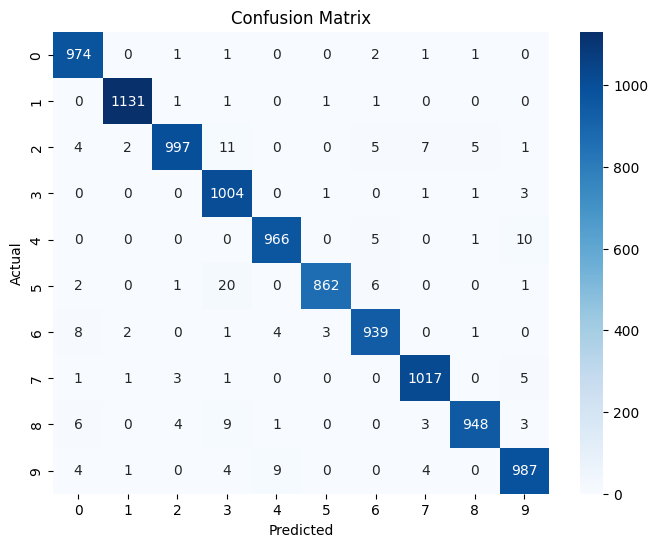

In [61]:
cm = confusion_matrix(y_true, y_pred_Classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()